# Demo workflow: factory scheduling, disruption rescheduling, KPI comparison, and Gantt charts

This notebook continues the previous steps and demonstrates the full demo workflow:

1. load the generated data,
2. build the baseline schedule,
3. recompute the schedule after a machine disruption,
4. compare KPIs,
5. visualize the result with a Gantt chart.

The notebook is designed for data that was generated earlier in the following format:
- `machines.csv`
- `orders.csv`
- `operations.csv`
- `shifts.csv`
- `downtime_events.csv`
- `scenarios.csv`

It also expects the solver module:
- `cp_sat_scheduler_github_style_fixed.py`

## What this scenario demonstrates

The scenario follows the selected demo idea: an **unexpected machine disruption** that creates a cascading effect and requires fast rescheduling. This clearly illustrates the difference between a static plan and real-time scheduling.

## Requirements

This notebook uses:
- `pandas`
- `numpy`
- `matplotlib`
- `ortools`

If `ortools` is not installed yet, the next cell will install it automatically.


In [1]:
# Install only ortools if it is not available yet.
# Important: do not reinstall pandas/numpy/matplotlib unless necessary,
# to avoid breaking environment compatibility.
import importlib.util
import sys

if importlib.util.find_spec('ortools') is None:
    !{sys.executable} -m pip install -q "ortools>=9.9,<10"
else:
    print('ortools is already installed')


ortools is already installed


## 1. Import libraries and configure paths

By default, the notebook points to the synthetic demo bundle that was created earlier.  
You can switch to `embedded_benchmark` if needed.


In [2]:
from pathlib import Path
import sys
import math

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Path to the data directory
DATA_ROOT = Path("generated_factory_demo_data")
BUNDLE_NAME = "synthetic_demo"   # can be changed to "embedded_benchmark"
BUNDLE_DIR = DATA_ROOT / BUNDLE_NAME

# Path to the solver module
MODULE_PATH = Path("cp_sat_scheduler.py")

print("Bundle dir:", BUNDLE_DIR.resolve())
print("Module path:", MODULE_PATH.resolve())

if not MODULE_PATH.exists():
    raise FileNotFoundError(
        "The file cp_sat_scheduler.py was not found next to the notebook. "
        "Download it together with the notebook or update MODULE_PATH."
    )

sys.path.append(str(MODULE_PATH.parent.resolve()))

from cp_sat_scheduler import (
    load_data_bundle,
    solve_schedule,
    run_reschedule_on_event,
    compute_kpis,
    export_schedule_csv,
    validate_schedule,
)


Bundle dir: /datasets/_deepnote_work/optimal_scheduling/generated_factory_demo_data/synthetic_demo
Module path: /datasets/_deepnote_work/optimal_scheduling/cp_sat_scheduler.py


## 2. Load the data and review the structure

First, load the bundle and inspect the tables. This helps confirm that the structure matches the solver expectations.


In [3]:
bundle = load_data_bundle(BUNDLE_DIR)

print("Machines:", bundle.machines.shape)
print("Orders:", bundle.orders.shape)
print("Operations:", bundle.operations.shape)
print("Shifts:", bundle.shifts.shape)
print("Downtime events:", bundle.downtime_events.shape)
print("Scenarios:", bundle.scenarios.shape)

print("\nMachines preview:")
print(bundle.machines.head().to_string(index=False))
print("\nOrders preview:")
print(bundle.orders.head().to_string(index=False))
print("\nOperations preview:")
print(bundle.operations.head().to_string(index=False))
print("\nScenarios:")
print(bundle.scenarios.to_string(index=False))


Machines: (8, 6)
Orders: (30, 7)
Operations: (116, 10)
Shifts: (24, 4)
Downtime events: (3, 7)
Scenarios: (4, 6)

Machines preview:
machine_id machine_group machine_name  daily_capacity_minutes  efficiency  can_preempt
  M_CUT_01           CUT     M CUT 01                     540       0.925        False
  M_CUT_02           CUT     M CUT 02                     540       1.040        False
 M_WELD_01          WELD    M WELD 01                     540       0.996        False
 M_WELD_02          WELD    M WELD 02                     540       0.970        False
M_PAINT_01         PAINT   M PAINT 01                     540       0.881        False

Orders preview:
order_id product_family  priority priority_label        release_time            deadline customer_segment
 ORD_001        FRAME_A         3         normal 2026-04-20 08:10:00 2026-04-20 18:21:00              OEM
 ORD_002        FRAME_A         1       critical 2026-04-20 09:05:00 2026-04-20 21:24:00          Service
 ORD_003   

## 3. Solve the baseline scheduling problem

This step builds the initial schedule without any disruption.  
It serves as the **reference plan** that will later be compared against the repaired schedule.

> Note: the solver uses CP-SAT and accounts for:
> - machine no-overlap,
> - operation precedence within each order,
> - deadlines and priorities,
> - shift calendars,
> - assignment to eligible machine groups.


In [4]:
baseline = solve_schedule(
    BUNDLE_DIR,
    scenario_name="baseline_no_disruption",
    time_limit_seconds=20,
    num_search_workers=8,
)

print("Baseline status:", baseline.status)
print("Baseline objective:", baseline.objective_value)
print("Baseline solve time [s]:", round(baseline.solve_time_seconds, 3))

if baseline.status != "OPTIMAL":
    print("Warning: baseline solve finished as FEASIBLE, not OPTIMAL.")
    print("This schedule is valid, but it is not proven globally optimal.")

if baseline.status not in {"OPTIMAL", "FEASIBLE"}:
    raise RuntimeError("Baseline schedule was not solved successfully.")

print("\nBaseline schedule head:")
print(baseline.schedule.head(20).to_string(index=False))
print("\nBaseline order summary head:")
print(baseline.order_summary.head(20).to_string(index=False))
print("\nNaN machine_id in baseline:", baseline.schedule["machine_id"].isna().sum())

baseline_validation = validate_schedule(
    baseline.schedule,
    bundle,
    scenario_name='baseline_no_disruption',
)
print("\nBaseline validation:")
print(pd.DataFrame([baseline_validation]).T.rename(columns={0: 'value'}).to_string())


Baseline status: FEASIBLE
Baseline objective: 9007510.0
Baseline solve time [s]: 19.985
This schedule is valid, but it is not proven globally optimal.

Baseline schedule head:
 operation_id order_id  sequence_index machine_group_required machine_id  start_minute  end_minute          start_time            end_time  processing_time_minutes  setup_time_minutes  scheduled_duration_minutes  active_work_minutes  was_in_progress_at_replan
ORD_009_OP_01  ORD_009               1                    CUT   M_CUT_01            10          80 2026-04-20 08:10:00 2026-04-20 09:20:00                       50                  20                          70                   70                      False
ORD_026_OP_01  ORD_026               1                   WELD  M_WELD_01            10          75 2026-04-20 08:10:00 2026-04-20 09:15:00                       55                  10                          65                   65                      False
ORD_006_OP_01  ORD_006               1      

## 4. Compute KPI values for the baseline

Compute the core metrics:
- makespan,
- total tardiness,
- number of late orders,
- priority-weighted tardiness,
- machine idle time.


In [5]:
baseline_kpis = compute_kpis(
    baseline.schedule,
    bundle.orders,
    bundle.operations,
    bundle.shifts,
)

baseline_kpis_df = pd.DataFrame([baseline_kpis]).T.reset_index()
baseline_kpis_df.columns = ["metric", "baseline_value"]
print(baseline_kpis_df.to_string(index=False))


                                     metric  baseline_value
                   num_scheduled_operations           116.0
                                 num_orders            30.0
                           makespan_minutes          3405.0
                    total_tardiness_minutes         40203.0
                                late_orders            22.0
                priority_weighted_tardiness         90046.0
   machine_idle_minutes_inside_used_windows          1136.0
average_operation_shift_minutes_vs_previous             NaN
             changed_operations_vs_previous             NaN


## 5. Review the available disruption scenarios

The bundle already contains multiple scenarios:
- `baseline_no_disruption`
- `optimistic_estimate`
- `pessimistic_estimate`
- `updated_after_10_min`

For the demo, it is usually convenient to start with `optimistic_estimate` and then show how the result changes under a worse estimate or after updated information arrives.


In [6]:
print(bundle.scenarios.to_string(index=False))

SCENARIO_NAME = "optimistic_estimate"
USE_ACTUAL_DOWNTIME = False   # True -> use actual_duration_minutes, False -> use estimated_duration_minutes

print("Selected scenario:", SCENARIO_NAME)
print("Use actual downtime:", USE_ACTUAL_DOWNTIME)

print(bundle.downtime_events[bundle.downtime_events["scenario_name"] == SCENARIO_NAME].to_string(index=False))


         scenario_name                                                 description machine_id         event_start  estimated_duration_minutes  actual_duration_minutes
baseline_no_disruption                       Initial plan without machine stoppage        NaN                 NaT                           0                        0
   optimistic_estimate                   Stoppage initially estimated as 5 minutes  M_WELD_01 2026-04-20 10:30:00                           5                       20
  pessimistic_estimate                  Stoppage initially estimated as 20 minutes  M_WELD_01 2026-04-20 10:30:00                          20                       20
  updated_after_10_min Initial estimate 5 min, then updated to 20 min after 10 min  M_WELD_01 2026-04-20 10:30:00                           5                       20
Selected scenario: optimistic_estimate
Use actual downtime: False
event_id machine_id         event_start  estimated_duration_minutes  actual_duration_minutes       

## 6. Reschedule after the disruption event

Now reuse the baseline plan and run **rolling rescheduling** after the machine disruption event.

Key setting:
- `freeze_started_operations=True` means that operations already in progress are not interrupted and remain fixed.  
This matches a typical non-preemptive manufacturing scenario.


In [7]:
repaired = run_reschedule_on_event(
    BUNDLE_DIR,
    baseline.schedule,
    scenario_name=SCENARIO_NAME,
    freeze_started_operations=True,
    use_actual_downtime=USE_ACTUAL_DOWNTIME,
    time_limit_seconds=20,
    num_search_workers=8,
)

print("Repair status:", repaired.status)
print("Repair objective:", repaired.objective_value)
print("Repair solve time [s]:", round(repaired.solve_time_seconds, 3))

if repaired.status != "OPTIMAL":
    print("Warning: repaired solve finished as FEASIBLE, not OPTIMAL.")
    print("This means KPI/objective comparison is useful for demo purposes,")
    print("but should not be interpreted as a proof that repaired is globally better.")

if repaired.status not in {"OPTIMAL", "FEASIBLE"}:
    raise RuntimeError("Repaired schedule was not solved successfully.")

print("\nRepaired schedule head:")
print(repaired.schedule.head(20).to_string(index=False))
print("\nRepaired order summary head:")
print(repaired.order_summary.head(20).to_string(index=False))
print("\nNaN machine_id in repaired:", repaired.schedule["machine_id"].isna().sum())

repaired_validation = validate_schedule(
    repaired.schedule,
    bundle,
    scenario_name=SCENARIO_NAME,
    use_actual_downtime=USE_ACTUAL_DOWNTIME,
    replan_time=repaired.metadata.get('replan_time'),
)
print("\nRepaired validation:")
print(pd.DataFrame([repaired_validation]).T.rename(columns={0: 'value'}).to_string())


Repair status: FEASIBLE
Repair objective: 8766755.0
Repair solve time [s]: 19.966
This means KPI/objective comparison is useful for demo purposes,
but should not be interpreted as a proof that repaired is globally better.

Repaired schedule head:
 operation_id order_id  sequence_index machine_group_required machine_id  start_minute  end_minute          start_time            end_time  processing_time_minutes  setup_time_minutes  scheduled_duration_minutes  active_work_minutes  was_in_progress_at_replan
ORD_009_OP_01  ORD_009               1                    CUT   M_CUT_01            10          80 2026-04-20 08:10:00 2026-04-20 09:20:00                       50                  20                          70                   70                      False
ORD_026_OP_01  ORD_026               1                   WELD  M_WELD_01            10          75 2026-04-20 08:10:00 2026-04-20 09:15:00                       55                  10                          65                   65 

## 7. KPI values after rescheduling and comparison to the baseline

Now compute the metrics for the repaired schedule and the stability metrics relative to the baseline:
- average operation shift,
- number of changed operations.


In [8]:
repaired_kpis = compute_kpis(
    repaired.schedule,
    bundle.orders,
    bundle.operations,
    bundle.shifts,
    previous_schedule_df=baseline.schedule,
)

comparison_df = pd.DataFrame({
    "metric": sorted(set(baseline_kpis.keys()) | set(repaired_kpis.keys()))
})
comparison_df["baseline"] = comparison_df["metric"].map(baseline_kpis)
comparison_df["repaired"] = comparison_df["metric"].map(repaired_kpis)
comparison_df["delta_repaired_minus_baseline"] = comparison_df["repaired"] - comparison_df["baseline"]

print(comparison_df.to_string(index=False))


                                     metric  baseline  repaired  delta_repaired_minus_baseline
average_operation_shift_minutes_vs_previous       NaN    578.75                            NaN
             changed_operations_vs_previous       NaN     95.00                            NaN
                                late_orders      22.0     22.00                            0.0
   machine_idle_minutes_inside_used_windows    1136.0   1390.00                          254.0
                           makespan_minutes    3405.0   3400.00                           -5.0
                                 num_orders      30.0     30.00                            0.0
                   num_scheduled_operations     116.0    116.00                            0.0
                priority_weighted_tardiness   90046.0  87638.00                        -2408.0
                    total_tardiness_minutes   40203.0  40901.00                          698.0


## 8. Export schedules

If the result needs to be consumed by a UI or backend service, the baseline and repaired schedules can be exported as CSV files.


In [9]:
OUTPUT_DIR = Path("scheduler_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

baseline_path = OUTPUT_DIR / f"{BUNDLE_NAME}_baseline_schedule.csv"
repaired_path = OUTPUT_DIR / f"{BUNDLE_NAME}_{SCENARIO_NAME}_repaired_schedule.csv"

export_schedule_csv(baseline.schedule, baseline_path)
export_schedule_csv(repaired.schedule, repaired_path)

print("Saved:", baseline_path.resolve())
print("Saved:", repaired_path.resolve())


Saved: /datasets/_deepnote_work/optimal_scheduling/scheduler_outputs/synthetic_demo_baseline_schedule.csv
Saved: /datasets/_deepnote_work/optimal_scheduling/scheduler_outputs/synthetic_demo_optimistic_estimate_repaired_schedule.csv


## 9. Helper function for the Gantt chart

The function below provides a simple visualization:
- each row corresponds to one machine,
- color represents the order,
- the chart can show either the baseline or the repaired schedule,
- downtime can be overlaid as a semi-transparent block.


In [10]:
def plot_gantt_v2(
    schedule_df,
    title,
    downtime_df=None,
    shifts_df=None,
    event_time=None,
    label_mode="order",   # operation | order | none
    min_label_minutes=85,
    machine_order=None,
    downtime_duration_col="estimated_duration_minutes",
    figsize=(18, 7),
    xlim_mode="shift_span",   # shift_span | data_span
    edge_padding_minutes=15,
):
    df = schedule_df.copy()
    df["start_time"] = pd.to_datetime(df["start_time"])
    df["end_time"] = pd.to_datetime(df["end_time"])

    if machine_order is None:
        machines = list(df["machine_id"].dropna().astype(str).sort_values().unique())
    else:
        machines = list(machine_order)

    machine_to_y = {m: i for i, m in enumerate(machines)}

    fig, ax = plt.subplots(figsize=figsize)

    order_ids = sorted(df["order_id"].astype(str).unique())
    cmap = plt.colormaps["tab20"]
    order_to_color = {oid: cmap(i % 20) for i, oid in enumerate(order_ids)}

    # ---------- Main operation bars ----------
    for _, row in df.iterrows():
        machine_id = row["machine_id"]
        if pd.isna(machine_id) or str(machine_id) not in machine_to_y:
            continue

        y = machine_to_y[str(machine_id)]
        start = mdates.date2num(row["start_time"])
        end = mdates.date2num(row["end_time"])
        width = end - start
        duration_min = (row["end_time"] - row["start_time"]).total_seconds() / 60.0

        ax.barh(
            y=y,
            width=width,
            left=start,
            height=0.62,
            color=order_to_color[str(row["order_id"])],
            edgecolor="black",
            linewidth=0.8,
            alpha=0.9,
        )

        if duration_min >= min_label_minutes and label_mode != "none":
            if label_mode == "operation":
                label = f"{row['order_id']} / op{row['sequence_index']}"
            else:
                label = str(row["order_id"])

            ax.text(
                start + width / 2,
                y,
                label,
                ha="center",
                va="center",
                fontsize=8,
                color="black",
            )

    # ---------- Downtime windows ----------
    downtime_legend_needed = False
    event_times = []

    if downtime_df is not None and not downtime_df.empty:
        tmp = downtime_df.copy()
        tmp["event_start"] = pd.to_datetime(tmp["event_start"])
        event_times.extend(tmp["event_start"].dropna().tolist())

        for _, row in tmp.iterrows():
            machine_id = str(row["machine_id"])
            if machine_id not in machine_to_y:
                continue

            duration = row.get(downtime_duration_col, None)
            if pd.isna(duration):
                continue

            y = machine_to_y[machine_id]
            start = mdates.date2num(row["event_start"])
            end = mdates.date2num(
                row["event_start"] + pd.Timedelta(minutes=float(duration))
            )

            ax.barh(
                y=y,
                width=end - start,
                left=start,
                height=0.84,
                color="red",
                alpha=0.18,
                edgecolor="red",
                hatch="//",
                linewidth=1.0,
            )
            downtime_legend_needed = True

    # Also draw an explicitly provided event time as a vertical line.
    if event_time is not None and not pd.isna(event_time):
        event_times.append(pd.to_datetime(event_time))

    unique_event_times = sorted(pd.to_datetime(pd.Series(event_times).dropna().unique())) if event_times else []

    event_line_needed = False
    for idx, ts in enumerate(unique_event_times):
        x = mdates.date2num(pd.to_datetime(ts))
        ax.axvline(
            x=x,
            linestyle="--",
            linewidth=1.6,
            alpha=0.9,
        )
        label = "Downtime event" if idx == 0 else f"Event {idx + 1}"
        ax.text(
            x,
            len(machines) - 0.35 if machines else 0.0,
            label,
            rotation=90,
            ha="right",
            va="top",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7, edgecolor="none"),
        )
        event_line_needed = True

    # ---------- X-axis bounds ----------
    display_start = None
    display_end = None

    if xlim_mode == "shift_span" and shifts_df is not None and not shifts_df.empty:
        tmp_shifts = shifts_df.copy()
        tmp_shifts["shift_start"] = pd.to_datetime(tmp_shifts["shift_start"])
        tmp_shifts["shift_end"] = pd.to_datetime(tmp_shifts["shift_end"])

        # Keep only working shifts for the machines that are actually shown.
        if "is_working" in tmp_shifts.columns:
            working_mask = tmp_shifts["is_working"].fillna(False).astype(bool)
            tmp_shifts = tmp_shifts[working_mask]

        tmp_shifts = tmp_shifts[tmp_shifts["machine_id"].astype(str).isin(machines)]

        if not tmp_shifts.empty:
            display_start = tmp_shifts["shift_start"].min()
            display_end = tmp_shifts["shift_end"].max()

    if display_start is None or display_end is None:
        candidates_start = [df["start_time"].min()]
        candidates_end = [df["end_time"].max()]

        if downtime_df is not None and not downtime_df.empty:
            tmp = downtime_df.copy()
            tmp["event_start"] = pd.to_datetime(tmp["event_start"])
            candidates_start.append(tmp["event_start"].min())

            if downtime_duration_col in tmp.columns:
                dt_end = tmp["event_start"] + pd.to_timedelta(tmp[downtime_duration_col], unit="m")
                candidates_end.append(dt_end.max())

        if unique_event_times:
            candidates_start.append(min(unique_event_times))
            candidates_end.append(max(unique_event_times))

        display_start = min(pd.to_datetime(pd.Series(candidates_start).dropna()))
        display_end = max(pd.to_datetime(pd.Series(candidates_end).dropna()))

    display_start = pd.to_datetime(display_start) - pd.Timedelta(minutes=edge_padding_minutes)
    display_end = pd.to_datetime(display_end) + pd.Timedelta(minutes=edge_padding_minutes)

    ax.set_xlim(mdates.date2num(display_start), mdates.date2num(display_end))

    # ---------- Styling ----------
    ax.set_title(title, fontsize=14)
    ax.set_yticks(range(len(machines)))
    ax.set_yticklabels(machines, fontsize=10)
    ax.set_ylabel("Machine", fontsize=11)
    ax.set_xlabel("Time", fontsize=11)
    ax.xaxis_date()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
    ax.grid(axis="x", linestyle="--", alpha=0.35)
    plt.xticks(rotation=30, fontsize=10)

    legend_handles = []
    if downtime_legend_needed:
        legend_handles.append(
            Patch(
                facecolor="red",
                edgecolor="red",
                alpha=0.18,
                hatch="//",
                label="Downtime window",
            )
        )
    if event_line_needed:
        legend_handles.append(
            Line2D(
                [0],
                [0],
                linestyle="--",
                linewidth=1.6,
                label="Downtime event time",
            )
        )

    if legend_handles:
        ax.legend(handles=legend_handles, loc="upper right")

    plt.tight_layout()
    plt.show()


## 10. Visualize the baseline schedule

This is the original plan before the disruption.


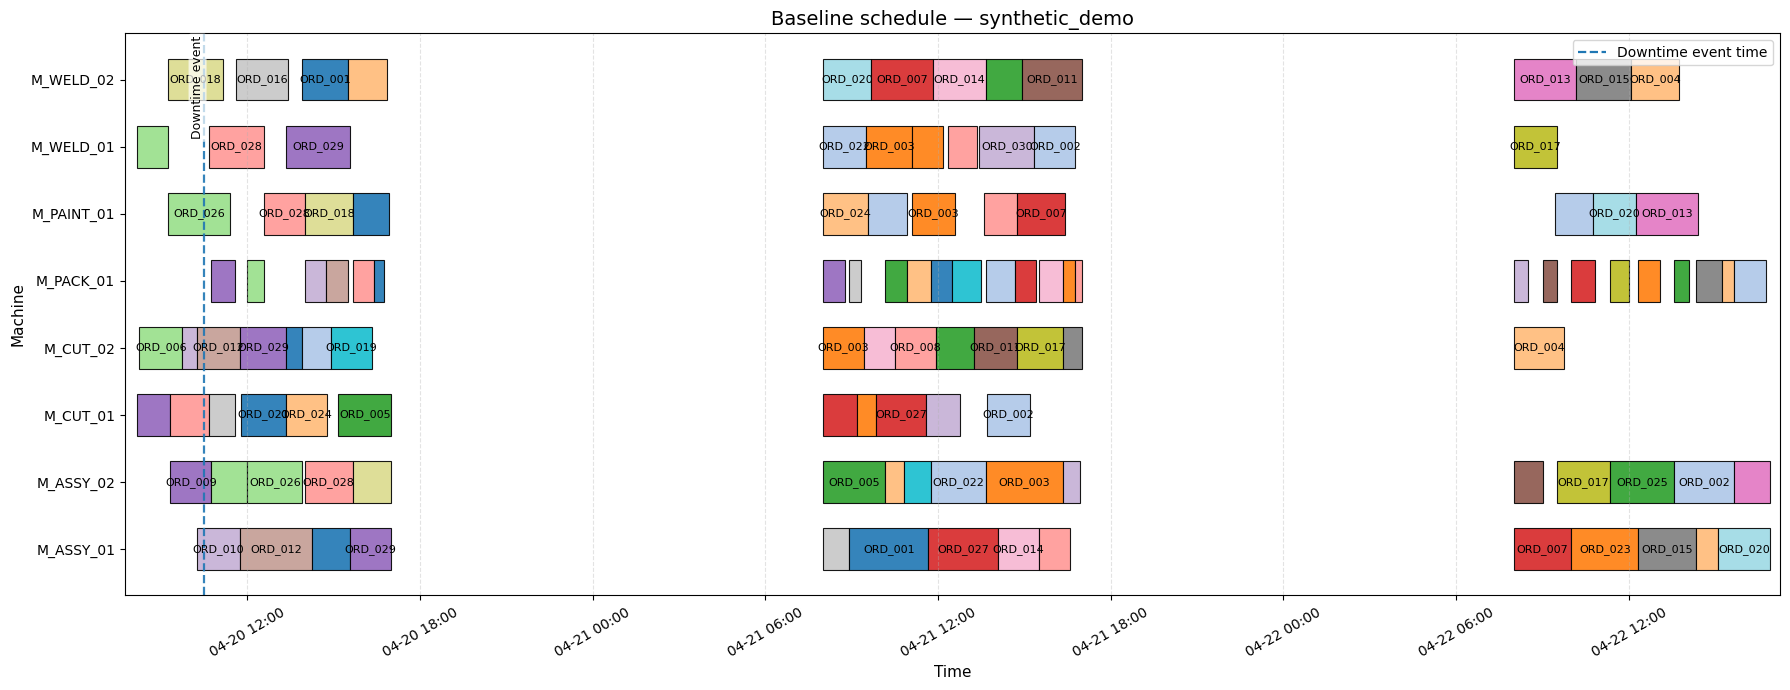

In [11]:
machine_order = sorted(
    set(baseline.schedule["machine_id"].dropna().astype(str).unique()).union(
        set(repaired.schedule["machine_id"].dropna().astype(str).unique())
    )
)

scenario_downtime = bundle.downtime_events[
    bundle.downtime_events["scenario_name"] == SCENARIO_NAME
].copy()
event_time_for_plot = None
if not scenario_downtime.empty:
    event_time_for_plot = pd.to_datetime(scenario_downtime["event_start"]).min()

plot_gantt_v2(
    baseline.schedule,
    title=f"Baseline schedule — {BUNDLE_NAME}",
    machine_order=machine_order,
    label_mode="order",
    min_label_minutes=85,
    downtime_df=None,
    shifts_df=bundle.shifts,
    event_time=event_time_for_plot,
    xlim_mode="shift_span",
    edge_padding_minutes=15,
)

## 11. Visualize the repaired schedule with downtime

This chart shows the effect of the disruption and the subsequent rescheduling.


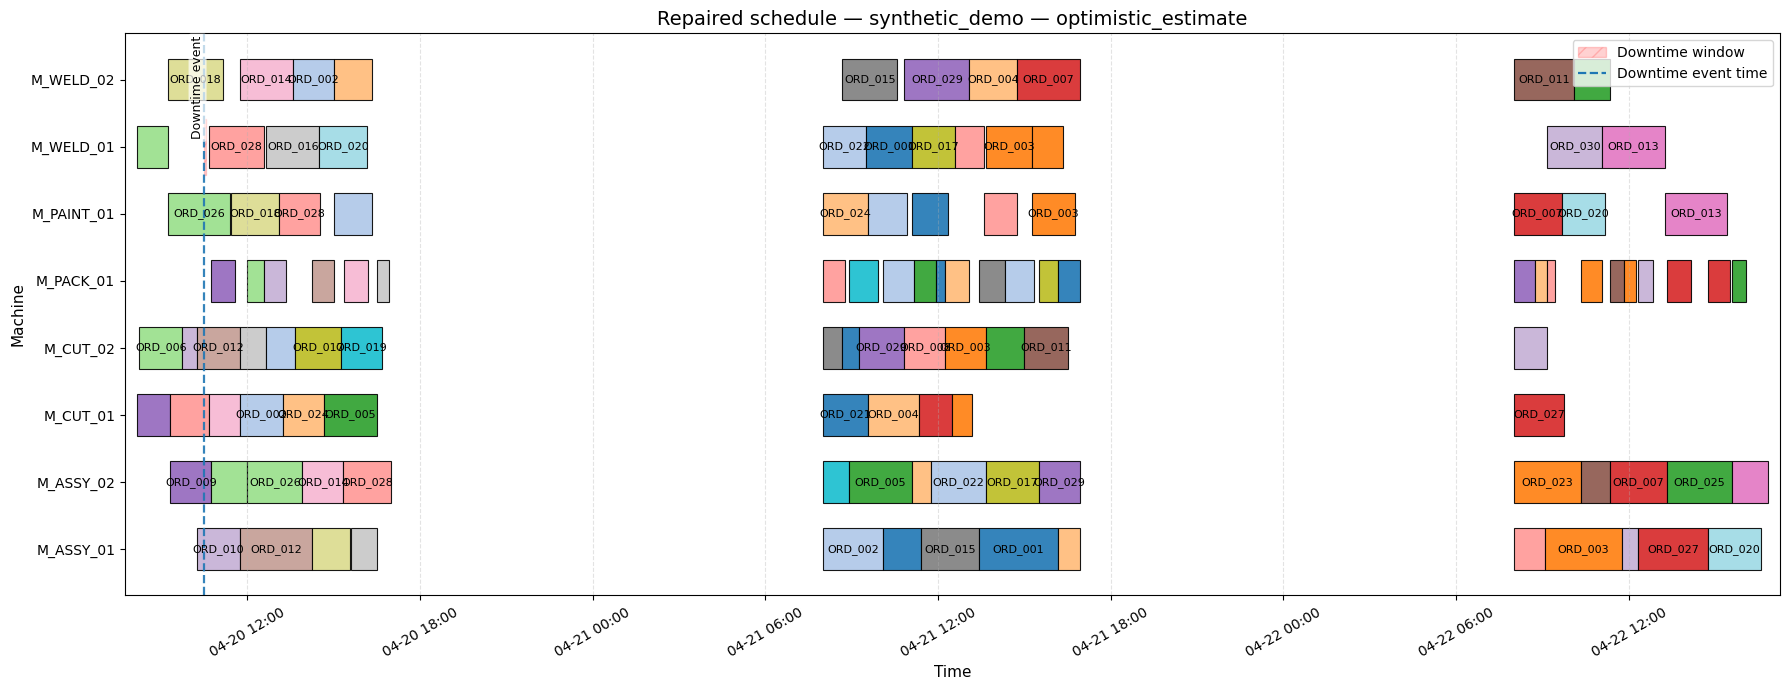

In [12]:
scenario_downtime = bundle.downtime_events[
    bundle.downtime_events["scenario_name"] == SCENARIO_NAME
].copy()

event_time_for_plot = None
if not scenario_downtime.empty:
    event_time_for_plot = pd.to_datetime(scenario_downtime["event_start"]).min()

plot_gantt_v2(
    repaired.schedule,
    title=f"Repaired schedule — {BUNDLE_NAME} — {SCENARIO_NAME}",
    machine_order=machine_order,
    label_mode="order",
    min_label_minutes=85,
    downtime_df=scenario_downtime,
    shifts_df=bundle.shifts,
    event_time=event_time_for_plot,
    downtime_duration_col=("actual_duration_minutes" if USE_ACTUAL_DOWNTIME else "estimated_duration_minutes"),
    xlim_mode="shift_span",
    edge_padding_minutes=15,
)

## 12. Compare baseline and repaired schedules only for changed operations

To make the ripple effect more explicit, it is useful to inspect only the operations that actually moved.


In [13]:
compare = repaired.schedule.merge(
    baseline.schedule[["operation_id", "machine_id", "start_time", "end_time"]].rename(columns={
        "machine_id": "baseline_machine_id",
        "start_time": "baseline_start_time",
        "end_time": "baseline_end_time",
    }),
    on="operation_id",
    how="left",
)

compare["baseline_start_time"] = pd.to_datetime(compare["baseline_start_time"])
compare["baseline_end_time"] = pd.to_datetime(compare["baseline_end_time"])
compare["start_time"] = pd.to_datetime(compare["start_time"])
compare["end_time"] = pd.to_datetime(compare["end_time"])

compare["start_shift_minutes"] = (
    (compare["start_time"] - compare["baseline_start_time"]).dt.total_seconds().abs() / 60.0
)
compare["machine_changed"] = compare["machine_id"] != compare["baseline_machine_id"]
compare["changed"] = compare["machine_changed"] | (compare["start_shift_minutes"] > 0.0)

changed_ops = compare[compare["changed"]].sort_values(
    "start_shift_minutes", ascending=False
)

print(
    changed_ops[
        [
            "operation_id",
            "order_id",
            "baseline_machine_id",
            "machine_id",
            "baseline_start_time",
            "start_time",
            "start_shift_minutes",
            "machine_changed",
        ]
    ].head(30).to_string(index=False)
)

print("Changed operations:", len(changed_ops))
print("Average operation shift [min]:", changed_ops["start_shift_minutes"].mean())


 operation_id order_id baseline_machine_id machine_id baseline_start_time          start_time  start_shift_minutes  machine_changed
ORD_002_OP_03  ORD_002          M_PAINT_01 M_PAINT_01 2026-04-22 09:25:00 2026-04-20 15:01:00               2544.0            False
ORD_002_OP_04  ORD_002           M_ASSY_02  M_ASSY_01 2026-04-22 13:35:00 2026-04-21 08:00:00               1775.0             True
ORD_002_OP_05  ORD_002           M_PACK_01  M_PACK_01 2026-04-22 15:40:00 2026-04-21 10:05:00               1775.0            False
ORD_002_OP_01  ORD_002            M_CUT_01   M_CUT_01 2026-04-21 13:41:00 2026-04-20 11:45:00               1556.0            False
ORD_002_OP_02  ORD_002           M_WELD_01  M_WELD_02 2026-04-21 15:21:00 2026-04-20 13:35:00               1546.0             True
ORD_015_OP_02  ORD_015           M_WELD_02  M_WELD_02 2026-04-22 10:10:00 2026-04-21 08:40:00               1530.0            False
ORD_017_OP_01  ORD_017            M_CUT_02   M_CUT_02 2026-04-21 14:45:00 20

## 13. Short business interpretation of the result

The cell below produces a short textual summary that can almost be used directly as commentary for a demo slide.


In [14]:
def summarize_demo_result(
    baseline_kpis,
    repaired_kpis,
    scenario_name,
    baseline_status=None,
    repaired_status=None,
):
    lines = []
    lines.append(f"Scenario: {scenario_name}")
    lines.append(
        f"Makespan changed from {baseline_kpis['makespan_minutes']:.1f} "
        f"to {repaired_kpis['makespan_minutes']:.1f} minutes."
    )
    lines.append(
        f"Total tardiness changed from {baseline_kpis['total_tardiness_minutes']:.1f} "
        f"to {repaired_kpis['total_tardiness_minutes']:.1f} minutes."
    )
    lines.append(
        f"Late orders changed from {baseline_kpis['late_orders']:.0f} "
        f"to {repaired_kpis['late_orders']:.0f}."
    )

    if not np.isnan(repaired_kpis.get("changed_operations_vs_previous", np.nan)):
        lines.append(
            f"Ripple effect: {repaired_kpis['changed_operations_vs_previous']:.0f} "
            f"operations changed relative to baseline."
        )

    if not np.isnan(repaired_kpis.get("average_operation_shift_minutes_vs_previous", np.nan)):
        lines.append(
            f"Average operation shift relative to baseline: "
            f"{repaired_kpis['average_operation_shift_minutes_vs_previous']:.1f} minutes."
        )

    if baseline_status != "OPTIMAL" or repaired_status != "OPTIMAL":
        lines.append(
            "Note: at least one schedule is FEASIBLE rather than OPTIMAL, "
            "so this comparison is useful for demo purposes but is not a proof of global superiority."
        )

    return "\n".join(lines)

print(
    summarize_demo_result(
        baseline_kpis,
        repaired_kpis,
        SCENARIO_NAME,
        baseline_status=baseline.status,
        repaired_status=repaired.status,
    )
)


Scenario: optimistic_estimate
Makespan changed from 3405.0 to 3400.0 minutes.
Total tardiness changed from 40203.0 to 40901.0 minutes.
Late orders changed from 22 to 22.
Ripple effect: 95 operations changed relative to baseline.
Average operation shift relative to baseline: 578.8 minutes.
Note: at least one schedule is FEASIBLE rather than OPTIMAL, so this comparison is useful for demo purposes but is not a proof of global superiority.


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=8cb529cf-bf9e-45d0-bc1e-3b3434c470fe' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>